# Visualise Graph

In [3]:
import matplotlib.pyplot as plt
import networkx as nx

# Define annotated graph
G = nx.DiGraph()

# Nodes with annotations (variables/state updates)
nodes = {
    "Start": {"vars": ["ticket_text"]},
    "Classifier Agent": {"vars": ["category", "confidence"]},
    "KB Retriever": {"vars": ["kb_docs"]},
    "Reply Drafter": {"vars": ["draft_reply"]},
    "Human Review (optional)": {"vars": ["approved_reply", "human_feedback"]},
    "Action Agent": {"vars": ["action_request", "tool_call_result"]},
    "Escalation": {"vars": ["escalation_ticket"]},
    "End": {"vars": []}
}

# Edges (flow transitions)
edges = [
    ("Start", "Classifier Agent"),
    ("Classifier Agent", "KB Retriever"),
    ("KB Retriever", "Reply Drafter"),
    ("Reply Drafter", "Human Review (optional)"),
    ("Human Review (optional)", "Reply Drafter"),  # loop on feedback
    ("Human Review (optional)", "Action Agent"),
    ("Action Agent", "Escalation"),
    ("Action Agent", "End"),
    ("Human Review (optional)", "Escalation"),
]

# Add nodes/edges
for node, attrs in nodes.items():
    label = f"{node}\n---\n" + "\n".join(attrs["vars"])
    G.add_node(node, label=label)

G.add_edges_from(edges)

# Draw annotated graph
plt.figure(figsize=(14, 9))
pos = nx.spring_layout(G, seed=42)
labels = nx.get_node_attributes(G, 'label')
nx.draw(G, pos, with_labels=False, node_size=7000, node_color="lightyellow", edgecolors="black", font_size=9, arrowsize=20)
nx.draw_networkx_labels(G, pos, labels=labels, font_size=8, verticalalignment="center")
plt.title("Customer Support Triage & Action Agent – LangGraph MVP Flow (with State Variables)", fontsize=12)
plt.axis("off")
plt.tight_layout()
plt.savefig("customer_support_triage_flow_annotated.png")
plt.close()


C:\Users\HARDIK JAIN\AppData\Local\Temp\ipykernel_25352\3283862763.py:47: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


# Agent 1

In [1]:
from agents.triage_agent import triage_agent, parse_triage_result

ticket = "What’s the difference between the basic and premium plans?"
output = triage_agent(ticket)
print(output)

ModelResponse(id='RcykaLKIN_KFz7IPzqe7kQw', created=1755630656, model='gemini-2.5-flash', object='chat.completion', system_fingerprint=None, choices=[Choices(finish_reason='stop', index=0, message=Message(content="<result>\n   <category>4</category>\n   <reason_for_category>The ticket is a direct question seeking clarification about the features and differences between product plans (basic vs. premium), which falls under product/service inquiry.</reason_for_category>\n   <confidence_for_category>100</confidence_for_category>\n   <urgency>1</urgency>\n   <reason_for_urgency_level>The ticket is purely informational and does not indicate any immediate problem or impact on the customer's ability to use the service, making it non-urgent.</reason_for_urgency_level>\n   <confidence_for_urgency_level>100</confidence_for_urgency_level>\n</result>", role='assistant', tool_calls=None, function_call=None, provider_specific_fields=None))], usage=Usage(completion_tokens=627, prompt_tokens=1158, tota

In [2]:
output_json = parse_triage_result(output.choices[0].message.content)
output_json

{'category': '4',
 'reason_for_category': 'The ticket is a direct question about the differences between product plans, which falls under seeking clarification about product features or plan details.',
 'confidence_for_category': '100',
 'urgency': '1',
 'reason_for_urgency_level': "The ticket is purely informational and does not indicate any immediate problem or impact on the customer's ability to use the service.",
 'confidence_for_urgency_level': '100'}

In [6]:
output.usage.dict()

{'completion_tokens': 570,
 'prompt_tokens': 1158,
 'total_tokens': 1728,
 'completion_tokens_details': {'accepted_prediction_tokens': None,
  'audio_tokens': None,
  'reasoning_tokens': 413,
  'rejected_prediction_tokens': None,
  'text_tokens': 157},
 'prompt_tokens_details': {'audio_tokens': None,
  'cached_tokens': None,
  'text_tokens': 1158,
  'image_tokens': None}}

## Create Custom Dataset

In [1]:
import pandas as pd
df = pd.read_csv("data/customer_support_tickets.csv")
df.head()  

,Ticket ID,Customer Name,Customer Email,Customer Age,Customer Gender,Product Purchased,Date of Purchase,Ticket Type,Ticket Subject,Ticket Description,Ticket Status,Resolution,Ticket Priority,Ticket Channel,First Response Time,Time to Resolution,Customer Satisfaction Rating
0,1,Marisa Obrien,carrollallison@example.com,32,Other,GoPro Hero,2021-03-22,Technical issue,Product setup,I'm having an issue with the {product_purchase...,Pending Customer Response,NaN,Critical,Social media,2023-06-01 12:15:36,NaN,NaN
1,2,Jessica Rios,clarkeashley@example.com,42,Female,LG Smart TV,2021-05-22,Technical issue,Peripheral compatibility,I'm having an issue with the {product_purchase...,Pending Customer Response,NaN,Critical,Chat,2023-06-01 16:45:38,NaN,NaN
2,3,Christopher Robbins,gonzalestracy@example.com,48,Other,Dell XPS,2020-07-14,Technical issue,Network problem,I'm facing a problem with my {product_purchase...,Closed,Case maybe show recently my computer follow.,Low,Social media,2023-06-01 11:14:38,2023-06-01 18:05:38,3.0
3,4,Christina Dillon,bradleyolson@example.org,27,Female,Microsoft Office,2020-11-13,Billing inquiry,Account access,I'm having an issue with the {product_purchase...,Closed,Try capital clearly never color toward story.,Low,Social media,2023-06-01 07:29:40,2023-06-01 01:57:40,3.0
4,5,Alexander Carroll,bradleymark@example.com,67,Female,Autodesk AutoCAD,2020-02-04,Billing inquiry,Data loss,I'm having an issue with the {product_purchase...,Closed,West decision evidence bit.,Low,Email,2023-06-01 00:12:42,2023-06-01 19:53:42,1.0


In [4]:
from pprint import pprint
pprint(df.loc[0, "Ticket Description"])

("I'm having an issue with the {product_purchased}. Please assist.\n"
 '\n'
 'Your billing zip code is: 71701.\n'
 '\n'
 'We appreciate that you have requested a website address.\n'
 '\n'
 "Please double check your email address. I've tried troubleshooting steps "
 'mentioned in the user manual, but the issue persists.')


In [25]:
df.__len__()

8469

In [26]:
df.columns

Index(['Ticket ID', 'Customer Name', 'Customer Email', 'Customer Age',
       'Customer Gender', 'Product Purchased', 'Date of Purchase',
       'Ticket Type', 'Ticket Subject', 'Ticket Description', 'Ticket Status',
       'Resolution', 'Ticket Priority', 'Ticket Channel',
       'First Response Time', 'Time to Resolution',
       'Customer Satisfaction Rating'],
      dtype='object')

In [43]:
def create_balanced_custom_dataset(df, total_rows=300):
    # Select and rename columns
    selected = df[['Ticket ID', 'Ticket Description', 'Ticket Type', 'Ticket Subject', 'Ticket Priority']].copy()
    selected = selected.rename(columns={
        'Ticket Type': 'GT Ticket Type',
        'Ticket Subject': 'GT Ticket Subject',
        'Ticket Priority': 'GT Ticket Priority'
    })

    # Find unique values for balancing
    type_classes = selected['GT Ticket Type'].unique()
    subject_classes = selected['GT Ticket Subject'].unique()
    priority_classes = selected['GT Ticket Priority'].unique()

    # Calculate minimum samples per class for each column
    min_type = total_rows // len(type_classes)
    min_subject = total_rows // len(subject_classes)
    min_priority = total_rows // len(priority_classes)

    # Sample balanced data for each class
    balanced_type = selected.groupby('GT Ticket Type').apply(lambda x: x.sample(min(len(x), min_type), random_state=42)).reset_index(drop=True)
    balanced_subject = selected.groupby('GT Ticket Subject').apply(lambda x: x.sample(min(len(x), min_subject), random_state=42)).reset_index(drop=True)
    balanced_priority = selected.groupby('GT Ticket Priority').apply(lambda x: x.sample(min(len(x), min_priority), random_state=42)).reset_index(drop=True)

    # Concatenate and drop duplicates to get final dataset
    balanced = pd.concat([balanced_type, balanced_subject, balanced_priority]).drop_duplicates().sample(n=min(total_rows, len(selected)), random_state=42).reset_index(drop=True)
    return balanced

# Example usage:
custom_dataset = create_balanced_custom_dataset(df, total_rows=30)
custom_dataset.to_csv("data/custom_tickets_dataset.csv", index=False)
custom_dataset.head()

,Ticket ID,Ticket Description,GT Ticket Type,GT Ticket Subject,GT Ticket Priority
0,4601,I'm having an issue with the {product_purchase...,Billing inquiry,Hardware issue,High
1,7362,I'm having an issue with the {product_purchase...,Refund request,Cancellation request,Low
2,1586,I'm facing issues logging into my {product_pur...,Refund request,Data loss,Medium
3,7070,I've noticed a software bug in the {product_pu...,Billing inquiry,Network problem,Low
4,1578,I'm having an issue with the {product_purchase...,Technical issue,Delivery problem,Medium


In [41]:
custom_dataset["GT Ticket Type"].value_counts()

GT Ticket Type
Billing inquiry         8
Product inquiry         7
Cancellation request    7
Technical issue         4
Refund request          4
Name: count, dtype: int64

## Loop to Test Dataset

In [ ]:
import pandas as pd
from agents.triage_agent import triage_agent, parse_triage_result
import time
from tqdm import tqdm

# Category and urgency mappings
category_map = {
    "1": "Billing & Payments",
    "2": "Technical Issues",
    "3": "Account Management",
    "4": "Product/Service Inquiry",
    "5": "Feature Requests / Feedback",
    "6": "Order & Delivery",
    "7": "Compliance / Legal / Security",
    "8": "General / Other"
}

urgency_map = {
    "1": "Low (Informational / Non-urgent)",
    "2": "Medium (Routine)",
    "3": "High (Time-Sensitive / Blocking)",
    "4": "Critical (Emergency / Escalation)"
}

# Read the dataset
df = pd.read_csv("data/selected_kaggle_tickets.csv")
result_df = df.iloc[:].copy()

for i, row in tqdm(result_df.iterrows(), total=len(result_df), desc="Tickets Processed"):
    ticket_text = row["Ticket Description"]
    print(f"\n{'='*30}\nProcessing Ticket #{i} | Ticket ID: {row['Ticket ID']} | Description: {ticket_text[:60]}...")
    # Time the agent call
    start_time = time.time()
    llm_output = triage_agent(ticket_text)
    end_time = time.time()
    elapsed = end_time - start_time
    # Parse output JSON
    parsed = parse_triage_result(llm_output.choices[0].message.content)
    # Collect relevant fields
    # Add new columns to the existing DataFrame
    result_df.loc[i, "LLM Output"] = llm_output.choices[0].message.content
    result_df.loc[i, "Predicted Ticket Type"] = category_map.get(parsed.get("category"), "Unknown")
    result_df.loc[i, "Predicted Ticket Priority"] = urgency_map.get(parsed.get("urgency"), "Unknown")
    result_df.loc[i, "Input Tokens"] = llm_output.usage.prompt_tokens
    result_df.loc[i, "Output Tokens"] = llm_output.usage.completion_tokens
    result_df.loc[i, "Total Tokens"] = llm_output.usage.total_tokens
    result_df.loc[i, "Time Taken"] = elapsed

    print(f"  Got the LLM Output -")
    print(f"  Parsed Category: {parsed.get('category')} ({category_map.get(parsed.get('category'), 'Unknown')})")
    print(f"  Parsed Urgency: {parsed.get('urgency')} ({urgency_map.get(parsed.get('urgency'), 'Unknown')})")
    print(f"  Input Tokens: {llm_output.usage.prompt_tokens}, Output Tokens: {llm_output.usage.completion_tokens}, Total: {llm_output.usage.total_tokens}")
    print(f"  Time Taken: {elapsed:.2f} seconds")
# Create a new DataFrame and save to CSV
result_df.to_csv("data/v1_res_selected_kaggle_tickets.csv", index=False)

Tickets Processed:   0%|          | 0/30 [00:00<?, ?it/s]


Processing Ticket #0 | Ticket ID: 4601 | Description: I'm having an issue with the {product_purchased}. Please ass...


Tickets Processed:   3%|▎         | 1/30 [00:08<04:10,  8.65s/it]

  Got the LLM Output -
  Parsed Category: 7 (Compliance / Legal / Security)
  Parsed Urgency: 3 (High (Time-Sensitive / Blocking))
  Input Tokens: 1220, Output Tokens: 1177, Total: 2397
  Time Taken: 8.63 seconds

Processing Ticket #1 | Ticket ID: 7362 | Description: I'm having an issue with the {product_purchased}. Please ass...


Tickets Processed:   7%|▋         | 2/30 [00:15<03:25,  7.35s/it]

...

  Got the LLM Output -
  Parsed Category: 2 (Technical Issues)
  Parsed Urgency: 2 (Medium (Routine))
  Input Tokens: 1210, Output Tokens: 1176, Total: 2386
  Time Taken: 7.78 seconds

Processing Ticket #28 | Ticket ID: 1384 | Description: I'm having trouble connecting my {product_purchased} to my h...


Tickets Processed:  97%|█████████▋| 29/30 [02:53<00:05,  5.64s/it]

  Got the LLM Output -
  Parsed Category: 2 (Technical Issues)
  Parsed Urgency: 3 (High (Time-Sensitive / Blocking))
  Input Tokens: 1225, Output Tokens: 599, Total: 1824
  Time Taken: 4.19 seconds

Processing Ticket #29 | Ticket ID: 7921 | Description: I'm having an issue with the {product_purchased}. Please ass...


Tickets Processed: 100%|██████████| 30/30 [02:59<00:00,  5.97s/it]

  Got the LLM Output -
  Parsed Category: 2 (Technical Issues)
  Parsed Urgency: 2 (Medium (Routine))
  Input Tokens: 1191, Output Tokens: 990, Total: 2181
  Time Taken: 5.69 seconds


## Confusion Metrix

In [4]:
print([
    'Billing & Payments',
    'Technical Issues',
    'Account Management',
    'Product/Service Inquiry',
    'Feature Requests / Feedback',
    'Order & Delivery',
    'Compliance / Legal / Security',
    'General / Other'
])

['Billing & Payments', 'Technical Issues', 'Account Management', 'Product/Service Inquiry', 'Feature Requests / Feedback', 'Order & Delivery', 'Compliance / Legal / Security', 'General / Other']


Confusion Matrix:


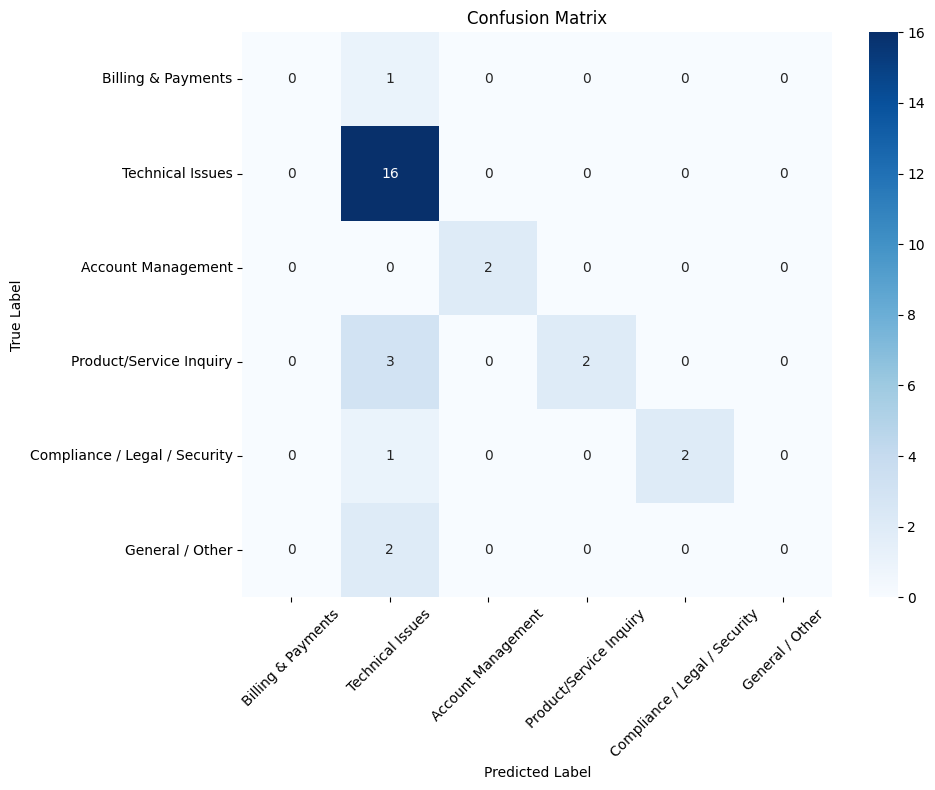

Accuracy: 0.7333
Macro Precision: 0.6111
Macro Recall: 0.5111
Macro F1-score: 0.5286


[0.7333333333333333, 0.611111111111111, 0.5111111111111111, 0.5285714285714286]

In [ ]:
import numpy as np
import pandas as pd
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, precision_score, recall_score, f1_score
import seaborn as sns
import matplotlib.pyplot as plt

# Define the class order
classes = [
    'Billing & Payments',
    'Technical Issues',
    'Account Management',
    'Product/Service Inquiry',
    'Feature Requests / Feedback',
    'Order & Delivery',
    'Compliance / Legal / Security',
    'General / Other'
]

def resolve_gt_label(row):
    gt = row['GT Ticket Type Manual']
    pred = row['Predicted Ticket Type']
    gt_labels = [label.strip() for label in str(gt).split('\n') if label.strip()]
    if len(gt_labels) == 1:
        return gt_labels[0]
    if pred in gt_labels:
        return pred
    return gt_labels[0]

def prepare_labels(df):
    gt_resolved = df.apply(resolve_gt_label, axis=1)
    pred_labels = df['Predicted Ticket Type'].values
    return gt_resolved, pred_labels

df = pd.read_csv("data/v1_res_selected_kaggle_tickets.csv")
gt_resolved, pred_labels = prepare_labels(df)

# Only keep classes that are present in GT
present_classes = [c for c in classes if c in gt_resolved.values]

cm = confusion_matrix(gt_resolved, pred_labels, labels=present_classes)
print("Confusion Matrix:")
cm_df = pd.DataFrame(cm, index=present_classes, columns=present_classes)

plt.figure(figsize=(10, 8))
sns.heatmap(cm_df, annot=True, fmt='d', cmap='Blues', cbar=True)
plt.title("Confusion Matrix")
plt.ylabel("True Label")
plt.xlabel("Predicted Label")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

acc = accuracy_score(gt_resolved, pred_labels)
print(f"Accuracy: {acc:.4f}")

macro_precision = precision_score(gt_resolved, pred_labels, labels=present_classes, average='macro', zero_division=0)
macro_recall = recall_score(gt_resolved, pred_labels, labels=present_classes, average='macro', zero_division=0)
macro_f1 = f1_score(gt_resolved, pred_labels, labels=present_classes, average='macro', zero_division=0)
print(f"Macro Precision: {macro_precision:.4f}")
print(f"Macro Recall: {macro_recall:.4f}")
print(f"Macro F1-score: {macro_f1:.4f}")
[acc, macro_precision, macro_recall, macro_f1]


In [8]:
"""
write python code to compute confusion matrix, classification report, accuracy, precision, recall, F1-score (take macro average) from a df with columns 'GT Ticket Type Manual' as true labels and 'Predicted Ticket Type' as predicted labels.
Also I somewhere used two labels in GT Ticket Type Manual column as options so if the predicted label matches any of those two labels, it should be considered a correct prediction and that label should its GT but if the predicted label does not match any of those two labels, it should be considered a wrong prediction and the first label in two options should be considered as GT for that row. The two GT labels are separated by a character like newline. So handle that in the code. Use macro average for precision, recall, and F1-score. The classes for true labels are defined below:
['Billing & Payments', 'Technical Issues', 'Account Management', 'Product/Service Inquiry', 'Feature Requests / Feedback', 'Order & Delivery', 'Compliance / Legal / Security', 'General / Other']
"""

"\nwrite python code to compute confusion matrix, classification report, accuracy, precision, recall, F1-score (take macro average) from a df with columns 'GT Ticket Type Manual' as true labels and 'Predicted Ticket Type' as predicted labels.\nAlso I somewhere used two labels in GT Ticket Type Manual column as options so if the predicted label matches any of those two labels, it should be considered a correct prediction and that label should its GT but if the predicted label does not match any of those two labels, it should be considered a wrong prediction and the first label in two options should be considered as GT for that row. The two GT labels are separated by a character like newline. So handle that in the code. Use macro average for precision, recall, and F1-score. The classes for true labels are defined below:\n"

# Agent 2

## Simple LangChain Agent with one RAG Tool

In [7]:
import getpass
import os
from dotenv import load_dotenv
load_dotenv()

if not os.environ.get("GOOGLE_API_KEY"):
  os.environ["GOOGLE_API_KEY"] = getpass.getpass("Enter API key for Google Gemini: ")

from langchain.chat_models import init_chat_model
model = init_chat_model("gemini-2.5-flash", model_provider="google_genai")

In [8]:
from langchain_core.messages import HumanMessage

response = model.invoke([HumanMessage(content="hi!")])
response.content

'Hi there! How can I help you today?'

In [14]:
from langchain_community.document_loaders import PyPDFLoader

file_path = "data/gold-hospital-and-premium-extras.pdf" 
loader = PyPDFLoader(file_path)
pages = []
async for page in loader.alazy_load():
    pages.append(page)


In [22]:
from langchain_text_splitters import RecursiveCharacterTextSplitter

documents = RecursiveCharacterTextSplitter(
    chunk_size=1000, chunk_overlap=200
).split_documents(pages)


In [31]:
from langchain_community.vectorstores import FAISS
from langchain_google_genai import GoogleGenerativeAIEmbeddings

embeddings_model = GoogleGenerativeAIEmbeddings(model="models/embedding-001")
vector = FAISS.from_documents(documents, embeddings_model)
retriever = vector.as_retriever()

In [39]:
retriever.invoke("rehabilitation period after shoulder recovery")

[Document(id='314664ae-59f2-40c7-8154-81e6d8d4e1d5', metadata={'producer': 'Adobe PDF Library 17.0', 'creator': 'Adobe InDesign 19.4 (Windows)', 'creationdate': '2025-03-24T12:36:03+11:00', 'moddate': '2025-03-24T12:36:32+11:00', 'trapped': '/False', 'source': 'data/gold-hospital-and-premium-extras.pdf', 'total_pages': 12, 'page': 1, 'page_label': '2'}, page_content='simply better benefits\nPlease read this document carefully and retain for future reference.'),
 Document(id='581bac09-bfc4-45e9-a6f9-9edb9afd309a', metadata={'producer': 'Adobe PDF Library 17.0', 'creator': 'Adobe InDesign 19.4 (Windows)', 'creationdate': '2025-03-24T12:36:03+11:00', 'moddate': '2025-03-24T12:36:32+11:00', 'trapped': '/False', 'source': 'data/gold-hospital-and-premium-extras.pdf', 'total_pages': 12, 'page': 4, 'page_label': '5'}, page_content='8 Ambulance services that are paid for by the Government, \ncompensation or other kinds of insurance\n8 Any transport provided by a non-recognised state \nambulance

In [49]:
from langchain.tools.retriever import create_retriever_tool

retriever_tool = create_retriever_tool(
    retriever,
    "insurance_policy_search",
    "Search for information about my insurance policy. For any questions about policy coverage, you must use this tool!",
)
tools = [retriever_tool]

In [50]:
from langchain import hub

# Get the prompt to use - you can modify this!
prompt = hub.pull("hwchase17/openai-functions-agent")
prompt.messages

d:\Projects\customer-support-triage-agent\.venv\Lib\site-packages\langsmith\client.py:272: LangSmithMissingAPIKeyWarning: API key must be provided when using hosted LangSmith API
  warnings.warn(


[SystemMessagePromptTemplate(prompt=PromptTemplate(input_variables=[], input_types={}, partial_variables={}, template='You are a helpful assistant'), additional_kwargs={}),
 MessagesPlaceholder(variable_name='chat_history', optional=True),
 HumanMessagePromptTemplate(prompt=PromptTemplate(input_variables=['input'], input_types={}, partial_variables={}, template='{input}'), additional_kwargs={}),
 MessagesPlaceholder(variable_name='agent_scratchpad')]

In [51]:
from langchain.agents import create_tool_calling_agent
from langchain.agents import AgentExecutor

agent = create_tool_calling_agent(model, tools, prompt)
agent_executor = AgentExecutor(agent=agent, tools=tools)

In [52]:
agent_executor.invoke({"input": "hi!"})

{'input': 'hi!', 'output': 'Hello! How can I help you today?\n'}

In [53]:
agent_executor.invoke({"input": "what is rehabilitation period after shoulder recovery under my policy?"})

{'input': 'what is rehabilitation period after shoulder recovery under my policy?',
 'output': 'Based on your policy, the waiting period for rehabilitation is 2 months. This would apply to shoulder recovery, as it falls under bone, joint, and muscle, and potentially joint reconstructions.'}

In [ ]:
import getpass
import os
from dotenv import load_dotenv
load_dotenv()


from langchain.chat_models import init_chat_model
from langchain_core.messages import SystemMessage, HumanMessage, AIMessage
model = init_chat_model("gemini-2.5-flash", model_provider="google_genai")


from langchain_community.document_loaders import PyPDFLoader
file_path = "data/gold-hospital-and-premium-extras.pdf" 
loader = PyPDFLoader(file_path)
pages = []
async for page in loader.alazy_load():
    pages.append(page)


from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_community.vectorstores import FAISS
from langchain_google_genai import GoogleGenerativeAIEmbeddings
documents = RecursiveCharacterTextSplitter(chunk_size=1000, chunk_overlap=200).split_documents(pages)
embeddings_model = GoogleGenerativeAIEmbeddings(model="models/embedding-001")
vector = FAISS.from_documents(documents, embeddings_model)
retriever = vector.as_retriever()


from langchain.tools.retriever import create_retriever_tool
retriever_tool = create_retriever_tool(
    retriever,
    "insurance_policy_search",
    "Search for information about my insurance policy. For any questions about policy coverage, you must use this tool!",
)
tools = [retriever_tool]


from langchain import hub
# Get the prompt to use - you can modify this!
prompt = hub.pull("hwchase17/openai-functions-agent")


from langchain.agents import create_tool_calling_agent
from langchain.agents import AgentExecutor
agent = create_tool_calling_agent(model, tools, prompt)
agent_executor = AgentExecutor(agent=agent, tools=tools)
agent_executor.invoke({"input": "what is rehabilitation period after shoulder recovery under my policy?"})

## Script to Generate Dummy Data

In [14]:
import os
import pandas as pd
import xml.etree.ElementTree as ET
from litellm import completion
from dotenv import load_dotenv
from tqdm import tqdm
import re

load_dotenv()

# Define categories
categories = {
    "billing": "Billing & Payments (refunds, invoices, double charges, payment methods)",
    "technical": "Technical Issues (troubleshooting errors, bugs, crashes, connectivity)",
    "account": "Account Management (password reset, profile updates, login issues)",
    "product": "Product/Service Inquiry (pricing, features, compatibility, usage guidance)",
    "feedback": "Feature Requests / Feedback (suggestions, improvements, user experience)",
    "orders": "Order & Delivery (shipping, tracking, cancellations, delays)",
    "compliance": "Compliance / Legal / Security (data privacy, terms of service, account security)",
    "general": "General / FAQ (policies, company guidelines, general support info)"
}

system_prompt = """
You are a Knowledge Base (KB) generator for a fictional customer support platform. Your task is to create realistic KB documents for a given support category.

OBJECTIVE:
Generate multiple distinct KB documents that cover different aspects, issues, or perspectives within the specified category.

DOCUMENT REQUIREMENTS:
- Each document must be unique and non-repetitive
- Title: 5-10 words, clear and descriptive
- Content: 150-300 words per document
- Types: Choose from FAQ, Article, Troubleshooting Guide, or Policy Note

CONTENT GUIDELINES:
- Use varied writing styles: step-by-step instructions, explanatory articles, policy statements, or Q&A format
- Ensure practical, actionable information
- Include specific details relevant to the category
- Avoid generic or vague content
- Make each document address a different sub-topic or scenario within the category
- Do not use any formatting marks like asterisks (*), double asterisks (**), or other special characters for emphasis
- Use plain text without any markdown formatting or highlighting

OUTPUT FORMAT:
Return your response as valid XML with the following structure:

<kbdocs>
    <doc>
        <title>[Brief descriptive title]</title>
        <type>[FAQ|Article|Troubleshooting Guide|Policy Note]</type>
        <content>[Detailed content addressing specific aspect of the category]</content>
    </doc>
    <doc>
        <title>[Different aspect title]</title>
        <type>[FAQ|Article|Troubleshooting Guide|Policy Note]</type>
        <content>[Content covering another unique perspective or issue]</content>
    </doc>
    ...
</kbdocs>

Formatting rules (strict):
- Output ONLY a single XML block exactly matching the above schema, no explanations outside the XML.
- DON'T use any prose, or markdown.
- Use plain ASCII quotes; avoid special characters.
- Content should be plain text without any formatting marks or emphasis characters.

IMPORTANT: Ensure each document within a category covers a distinct sub-topic to maximize knowledge base coverage.
"""

user_prompt_template = """
Generate {num_docs} distinct KB documents for below category:

Category name: {category_name}
Domain description: {domain_description}
"""

# Storage
all_data = []

print("Starting KB generation process")
os.makedirs("data/kb", exist_ok=True)

docs_per_category = 8

# Progress bar for categories
for cat_key, cat_desc in tqdm(categories.items(), desc="Processing categories"):
    print(f"Processing category: {cat_key}")
    
    user_prompt = user_prompt_template.format(
        num_docs=docs_per_category,
        category_name=cat_key.capitalize(),
        domain_description=cat_desc
    )
    
    response = completion(
        model="gemini/gemini-2.5-flash",
        messages=[
            {"role": "system", "content": system_prompt},
            {"role": "user", "content": user_prompt}
        ],
        temperature=0,
        top_p=0.5,
        max_tokens=8192
    )
    
    xml_content = response['choices'][0]['message']['content']
    xml_file = f"data/kb/{cat_key}.xml"
    
    with open(xml_file, "w", encoding="utf-8") as f:
        f.write(xml_content)
    
    # Parse XML → JSON → DataFrame rows
    try:
        # Parse XML using regex instead of ET
        docs_parsed = 0
        doc_pattern = r'<doc>(.*?)</doc>'
        docs = re.findall(doc_pattern, xml_content, re.DOTALL)

        for doc in docs:
            title_match = re.search(r'<title>(.*?)</title>', doc, re.DOTALL)
            type_match = re.search(r'<type>(.*?)</type>', doc, re.DOTALL)
            content_match = re.search(r'<content>(.*?)</content>', doc, re.DOTALL)
            
            if title_match and type_match and content_match:
                title = title_match.group(1).strip()
                doc_type = type_match.group(1).strip()
                content = content_match.group(1).strip()
                
                all_data.append({
                    "category": cat_key,
                    "title": title,
                    "type": doc_type,
                    "content": content
                })
                docs_parsed += 1

        print(f"✓ {cat_key}: {docs_parsed} documents parsed")
        
    except Exception as e:
        print(f"✗ Error parsing {cat_key}: {e}")
    
    print()

# Save combined dataset as CSV
print("Saving combined dataset...")
df = pd.DataFrame(all_data)
df.to_csv("data/kb/knowledge_base.csv", index=False, encoding="utf-8")
print(f"✅ Complete! {len(df)} documents saved to knowledge_base.csv")


Starting KB generation process


Processing categories:   0%|          | 0/8 [00:00<?, ?it/s]

Processing category: billing


Processing categories:  12%|█▎        | 1/8 [00:16<01:54, 16.32s/it]

✓ billing: 8 documents parsed

Processing category: technical


...

✓ orders: 8 documents parsed

Processing category: compliance


Processing categories:  88%|████████▊ | 7/8 [01:51<00:15, 15.18s/it]

✓ compliance: 8 documents parsed

Processing category: general


Processing categories: 100%|██████████| 8/8 [02:04<00:00, 15.56s/it]

✓ general: 8 documents parsed

Saving combined dataset...
✅ Complete! 64 documents saved to knowledge_base.csv


## Implementation of Required Agent 2

In [1]:
from agents.kb_agent import build_retrievers_from_csvs, build_agent

In [2]:
retrievers = build_retrievers_from_csvs()
agent_2 = build_agent(retrievers)

In [3]:
ticket = """
I'm having an issue with the {product_purchased}. Please assist.

-

What was it originally designed for?

Originally and hopefully in development, it was a means to create a "full stack" product at I've checked for software updates, and my {product_purchased} is already running the latest version.
"""

out = agent_2.invoke({
    "ticket_text": ticket,
    "category": "product",
    # "urgency": "medium"
})
print(out["output"])



> Entering new AgentExecutor chain...
Thought: I need to retrieve and consolidate knowledge relevant to the customer support ticket.
The ticket category is `product`.
According to the instructions, I MUST query:
1. The retriever for the ticket’s classified category: `product`.
2. The General/FAQs retriever: `general`.

The ticket text mentions an issue with a product, asks about its original design, and states that software updates have been checked. This information primarily falls under the `product` category. While "software updates" might have a `technical` aspect, the core of the ticket is about the product itself and its design, and the update status is provided as context to the product issue. I will stick to `product` and `general` as per the instructions to avoid querying unnecessary retrievers.

I will formulate the queries for both `product` and `general` using the relevant parts of the ticket text.

Action: product
Action Input: I'm having an issue with the {product_purch

In [ ]:
ticket = """
I'm having an issue with the {product_purchased}. Please assist.

-

What was it originally designed for?

Originally and hopefully in development, it was a means to create a "full stack" product at I've checked for software updates, and my {product_purchased} is already running the latest version.
"""

out = agent_2.invoke({
    "ticket_text": ticket,
    "category": "product",
    # "urgency": "medium"
})
print(out["output"])



> Entering new AgentExecutor chain...
Action: product
Action Input: issue with product, original design purpose, software updates, latest versionSnippet:
While the product may function on older operating systems or browsers, we cannot guarantee full functionality, performance, or security updates for unsupported environments. Users operating on unsupported systems may experience compatibility issues, reduced performance, or be unable to access new features. Our customer support team will provide limited assistance for issues encountered on unsupported platforms, primarily focusing on guiding users to upgrade to a supported environment. We recommend keeping your operating system and browser updated to ensure the best and most secure experience with our product.

(metadata: category=product, type=Policy Note, title=Supported Devices and Operating Systems Policy Note)
---
Snippet:
Deep Dive into Our Product's Real-time Data Sync Feature

The real-time data sync feature is a cornerstone 

In [41]:
ticket = "I was double charged yesterday and now I can't log in. Please fix this."
out = agent_2.invoke({
    "ticket_text": ticket,
    "category": "billing",
    "urgency": "high"
})
print(out["output"])



> Entering new AgentExecutor chain...
The user is reporting two issues: a double charge and an inability to log in.
The primary category identified by Agent 1 is 'billing', so I must query the 'billing' retriever.
I must also query the 'general' retriever as per the rules.
The inability to log in could also be related to 'account' or 'technical' issues, so I should consider querying those as well to get comprehensive information. Given the urgency and the dual nature of the problem, it's best to cover all bases.

Let's start with 'billing' and 'general', and then 'account' for the login issue.Action: billing
Action Input: I was double charged yesterdayThe user is reporting two issues: a double charge and an inability to log in.
The primary category identified by Agent 1 is 'billing', so I must query the 'billing' retriever.
I must also query the 'general' retriever as per the rules.
The inability to log in could also be related to 'account' or 'technical' issues, so I should consider

# Agent 3

In [ ]:
import re
from pprint import pprint

def parse_agent2_output_text(xml_text: str, narrative: bool = False) -> str:
    """
    Parse Agent 2's XML output into a clean narrative format for Agent 3.
    """

    # Extract individual retrieved sources
    sources = re.findall(
        r'<source retriever="(.*?)">\s*<summary>(.*?)</summary>\s*</source>',
        xml_text,
        re.DOTALL
    )

    # Extract consolidated context
    consolidated_match = re.search(r"<consolidated_context>(.*?)</consolidated_context>", xml_text, re.DOTALL)
    consolidated_context = consolidated_match.group(1).strip() if consolidated_match else "No consolidated summary available."

    if not narrative:
        return consolidated_context

    # --- Build narrative ---
    narrative_parts = []

    # Relevant Knowledge
    narrative_parts.append("Relevant Knowledge:")
    if sources:
        for retriever, summary in sources:
            summary_clean = " ".join(summary.split())
            narrative_parts.append(f"- {summary_clean} [{retriever}]")
    else:
        narrative_parts.append("- No relevant knowledge found.")

    narrative_parts.append("\nConsolidated Summary:")
    narrative_parts.append(consolidated_context)

    return "\n".join(narrative_parts)



In [2]:
from agents.reply_agent.crew import ReplyAgentCrew

In [3]:
ticket_text = """
I'm having an issue with the {product_purchased}. Please assist.

-

What was it originally designed for?

Originally and hopefully in development, it was a means to create a "full stack" product at I've checked for software updates, and my {product_purchased} is already running the latest version.
"""
print(ticket_text)


I'm having an issue with the {product_purchased}. Please assist.

-

What was it originally designed for?

Originally and hopefully in development, it was a means to create a "full stack" product at I've checked for software updates, and my {product_purchased} is already running the latest version.



In [ ]:
agent2_xml = """
<result>
  <retrieved_sources>
    <source retriever=""product"">
      <summary>The product's real-time data sync feature is a core design element, ensuring information is consistently updated across devices without manual intervention. Product performance can be optimized by regularly clearing the cache and ensuring the operating system and graphics drivers are up to date, as outdated drivers can cause compatibility issues. The product is available in Standard and Professional editions, each designed for different user requirements with varying core functionalities. Maintaining updated operating systems and browsers is recommended for full functionality, performance, and security, with limited support provided for unsupported environments. System specifications should be checked against published requirements to prevent installation failures or poor performance.</summary>
    </source>
    <source retriever=""general"">
      <summary>To effectively report a technical issue or bug, providing as much detail as possible is crucial for speeding up investigation and resolution.</summary>
    </source>
  </retrieved_sources>
  <consolidated_context>
    When experiencing an issue with the product, even if the product itself is running the latest version, it is recommended to ensure the operating system and graphics drivers are also up to date, as outdated drivers can lead to compatibility issues or reduced performance [product]. Regularly clearing the product's cache can also help optimize performance [product]. For optimal functionality, performance, and security, it is important to operate the product on supported devices and operating systems, and to keep browsers updated [product]. If system specifications fall below published requirements, it may result in installation failures or poor product performance [product].

    Regarding the product's design, a core feature is its real-time data sync, which automatically updates information across connected devices [product]. The product is offered in different editions, such as Standard and Professional, each tailored with specific features for varying user requirements [product].

    For reporting the issue, providing detailed information is essential for efficient investigation and resolution [general].
  </consolidated_context>
</result>
"""

context = parse_agent2_output_text(agent2_xml, narrative=True)
print(context)

Relevant Knowledge:
- The product's real-time data sync feature is a core design element, ensuring information is consistently updated across devices without manual intervention. Product performance can be optimized by regularly clearing the cache and ensuring the operating system and graphics drivers are up to date, as outdated drivers can cause compatibility issues. The product is available in Standard and Professional editions, each designed for different user requirements with varying core functionalities. Maintaining updated operating systems and browsers is recommended for full functionality, performance, and security, with limited support provided for unsupported environments. System specifications should be checked against published requirements to prevent installation failures or poor performance. ["product"]
- To effectively report a technical issue or bug, providing as much detail as possible is crucial for speeding up investigation and resolution. ["general"]

Consolidated 

In [5]:
def run(ticket_text, context):
    inputs = {
        "ticket_text": ticket_text,
        "context": context,
    }

    return ReplyAgentCrew().crew().kickoff(inputs)

In [8]:
reply = run(ticket_text, context)

Overriding of current TracerProvider is not allowed


Before kickoff function with inputs: {'ticket_text': '\nI\'m having an issue with the {product_purchased}. Please assist.\n\n-\n\nWhat was it originally designed for?\n\nOriginally and hopefully in development, it was a means to create a "full stack" product at I\'ve checked for software updates, and my {product_purchased} is already running the latest version.\n', 'context': 'Relevant Knowledge:\n- The product\'s real-time data sync feature is a core design element, ensuring information is consistently updated across devices without manual intervention. Product performance can be optimized by regularly clearing the cache and ensuring the operating system and graphics drivers are up to date, as outdated drivers can cause compatibility issues. The product is available in Standard and Professional editions, each designed for different user requirements with varying core functionalities. Maintaining updated operating systems and browsers is recommended for full functionality, performance,

ERROR:root:LiteLLM call failed: litellm.APIConnectionError: GeminiException - Server disconnected without sending a response.


# Agent: Reply Refinement Specialist
## Task: You are given a drafted customer support reply. Your job is review the drafted reply and check if it:
  - Fully addresses the customer's ticket. 
  - Accurately reflects the provided context (Relevant Knowledge + Consolidated Summary). 
  - Contains no hallucinations or unsupported claims. 
  - Maintains a professional, empathetic tone.
If issues are found, refine the reply accordingly. Otherwise, pass it through unchanged. Do not change factual content. Keep the reply aligned with professional business communication standards. Ensure the reply is concise, polite, easy to understand, and effectively addresses the user's concerns.



# Agent: Reply Refinement Specialist
## Final Answer: 
Hello,

Thank you for reaching out. I understand you're experiencing an issue with your {product_purchased}, and I appreciate you've already checked for the latest software updates.

Even with the product software updated, sometimes issues can stem from othe

In [9]:
print(reply)

Hello,

Thank you for reaching out. I understand you're experiencing an issue with your {product_purchased}, and I appreciate you've already checked for the latest software updates.

Even with the product software updated, sometimes issues can stem from other areas. To help optimize performance and resolve potential compatibility issues, we recommend the following:
*   **Update your operating system and graphics drivers:** Outdated drivers can sometimes lead to unexpected behavior.
*   **Clear the product's cache:** Regularly clearing the cache can help improve performance.
*   **Ensure your system meets requirements:** For optimal functionality, performance, and security, please ensure your operating system and browser are updated and that your system specifications meet the published requirements for the product.

Regarding your question about the product's design, a core feature is its **real-time data sync**, which ensures information is consistently updated across your devices wit

# Agent 4

In [ ]:
from agents.action_suggester_agent import action_suggester_agent, parse_action_suggester_result
from agents.kb_agent import parse_agent2_output_text

In [3]:
ticket_text = """
I'm having an issue with the {product_purchased}. Please assist.

-

What was it originally designed for?

Originally and hopefully in development, it was a means to create a "full stack" product at I've checked for software updates, and my {product_purchased} is already running the latest version.
"""
print(ticket_text)



I'm having an issue with the {product_purchased}. Please assist.

-

What was it originally designed for?

Originally and hopefully in development, it was a means to create a "full stack" product at I've checked for software updates, and my {product_purchased} is already running the latest version.



In [ ]:
agent2_xml = """
<result>
  <retrieved_sources>
    <source retriever=""product"">
      <summary>The product's real-time data sync feature is a core design element, ensuring information is consistently updated across devices without manual intervention. Product performance can be optimized by regularly clearing the cache and ensuring the operating system and graphics drivers are up to date, as outdated drivers can cause compatibility issues. The product is available in Standard and Professional editions, each designed for different user requirements with varying core functionalities. Maintaining updated operating systems and browsers is recommended for full functionality, performance, and security, with limited support provided for unsupported environments. System specifications should be checked against published requirements to prevent installation failures or poor performance.</summary>
    </source>
    <source retriever=""general"">
      <summary>To effectively report a technical issue or bug, providing as much detail as possible is crucial for speeding up investigation and resolution.</summary>
    </source>
  </retrieved_sources>
  <consolidated_context>
    When experiencing an issue with the product, even if the product itself is running the latest version, it is recommended to ensure the operating system and graphics drivers are also up to date, as outdated drivers can lead to compatibility issues or reduced performance [product]. Regularly clearing the product's cache can also help optimize performance [product]. For optimal functionality, performance, and security, it is important to operate the product on supported devices and operating systems, and to keep browsers updated [product]. If system specifications fall below published requirements, it may result in installation failures or poor product performance [product].

    Regarding the product's design, a core feature is its real-time data sync, which automatically updates information across connected devices [product]. The product is offered in different editions, such as Standard and Professional, each tailored with specific features for varying user requirements [product].

    For reporting the issue, providing detailed information is essential for efficient investigation and resolution [general].
  </consolidated_context>
</result>
"""

context = parse_agent2_output_text(agent2_xml, narrative=True)
print(context)

Relevant Knowledge:
- The product's real-time data sync feature is a core design element, ensuring information is consistently updated across devices without manual intervention. Product performance can be optimized by regularly clearing the cache and ensuring the operating system and graphics drivers are up to date, as outdated drivers can cause compatibility issues. The product is available in Standard and Professional editions, each designed for different user requirements with varying core functionalities. Maintaining updated operating systems and browsers is recommended for full functionality, performance, and security, with limited support provided for unsupported environments. System specifications should be checked against published requirements to prevent installation failures or poor performance. ["product"]
- To effectively report a technical issue or bug, providing as much detail as possible is crucial for speeding up investigation and resolution. ["general"]

Consolidated 

In [5]:
inputs = {
    "ticket_text": ticket_text,
    "category": "product",
    "urgency": "medium",
    "narrative_context": context,
}

In [6]:
agent_4_output = action_suggester_agent(inputs)

In [9]:
print(agent_4_output.choices[0].message.content)

<result>
  <suggested_actions>
    <action name="create_support_ticket">
      <arguments>
        <arg key="issue_summary">Customer is having an issue with {product_purchased} despite it running the latest version.</arg>
        <arg key="urgency">medium</arg>
        <arg key="related_category">product</arg>
      </arguments>
    </action>
  </suggested_actions>
</result>


In [12]:
parsed_actions = parse_action_suggester_result(agent_4_output.choices[0].message.content)
print(parsed_actions)

[{'name': 'create_support_ticket', 'arguments': {'issue_summary': 'Customer is having an issue with {product_purchased} despite it running the latest version.', 'urgency': 'medium', 'related_category': 'product'}}]


# ETE

In [ ]:
from agents.triage_agent import triage_agent, parse_triage_result
from agents.kb_agent import build_retrievers_from_csvs, build_agent, parse_agent2_output_text
from agents.reply_agent.crew import ReplyAgentCrew, reply_agent
from agents.action_suggester_agent import action_suggester_agent, parse_action_suggester_result

In [ ]:
import random

# Sample tickets for different categories

tickets = {
    "billing": [
        "I was double charged for my subscription on December 15th, 2024. Transaction IDs are TXN12345 and TXN12346, both for $29.99. I've compared this against my account billing history and confirmed these are duplicates. I also can't log in to my account now - getting 'invalid credentials' error despite using correct password. My account number is ACC789123. Please investigate the double charge and help me regain access to my account.",
        "My credit card was declined when trying to upgrade to premium plan. The card works fine elsewhere and has sufficient funds. Error message says 'Payment processing failed - contact support'. Can you help me complete the upgrade?",
        "I need a refund for the annual subscription I purchased yesterday. Due to budget constraints, I can no longer afford this service. Order number is ORD456789.",
        "Invoice #INV-2024-001 shows incorrect tax calculation. I'm in Delaware (no sales tax) but was charged 8.5% tax totaling $15.30. Please correct and issue credit."
    ],
    
    "technical": [
        "The application crashes every time I try to export data to PDF. Error code: ERR_EXPORT_FAILED. I'm using Windows 11, Chrome browser version 120.0.6099.216. This started happening after the latest update.",
        "I can't sync my data across devices. Files uploaded on desktop don't appear on mobile app. Both devices are connected to internet and logged into same account. Last successful sync was 3 days ago.",
        "Getting 'Server timeout' error when trying to load my dashboard. The page loads for about 30 seconds then shows error message. Other pages work fine. This happens on both Chrome and Firefox.",
        "Video calls keep dropping after 5-10 minutes. Audio quality is poor with echo and delays. My internet speed is 100 Mbps download, 20 Mbps upload. Using latest version of your desktop app on macOS Monterey."
    ],
    
    "account": [
        "I forgot my password and the reset email isn't arriving. I've checked spam folder and tried multiple times. My registered email is john.doe@email.com. Account was created in 2023.",
        "Need to update my profile information. Changed companies and need to update business email from old@company.com to new@newcompany.com. Also need to change billing address.",
        "My account was suspended without warning. I received email saying 'Terms of Service violation' but no specific details. I haven't done anything unusual. Please review and reactivate my account.",
        "Want to delete my account permanently and remove all personal data. I understand this action cannot be undone. Please confirm the deletion process and timeline."
    ],
    
    "product": [
        "What's included in the Professional plan versus Basic plan? I need advanced reporting features and wondering if upgrade is worth it. Currently have 50 users.",
        "Does your software integrate with Salesforce? We're migrating our CRM and need to ensure data sync capabilities. Also need API documentation if available.",
        "I'm having trouble understanding how to set up automated workflows. The documentation mentions triggers and actions but I can't find the setup page. Can you provide step-by-step guidance?",
        "What are the system requirements for the new mobile app? My device is iPhone 12 Pro running iOS 15. Will all features be available on mobile version?"
    ],
    
    "feedback": [
        "The new dashboard design is confusing. The navigation menu is hard to find and report generation takes too many clicks. Previous version was much more intuitive. Please consider reverting or providing classic view option.",
        "Feature request: ability to schedule automated reports via email. Currently I have to manually generate and send reports weekly. This would save significant time for our team.",
        "Love the recent performance improvements! Page load times are much faster. However, could you add dark mode theme? Working late hours and the bright interface strains my eyes.",
        "The search function needs improvement. It doesn't find results for partial matches or synonyms. For example, searching 'invoice' doesn't return 'billing' results. Please enhance search algorithm."
    ],
    
    "orders": [
        "My order #ORD789456 shipped 5 days ago but tracking shows no updates since 'Package in transit'. Expected delivery was yesterday. Can you check with shipping carrier?",
        "Need to cancel order #ORD123789 placed this morning. Haven't received shipping confirmation yet. Please cancel and refund to original payment method.",
        "Received wrong item in my order. Ordered Pro license key but received Basic license. Order number ORD654321. Need correct license key sent ASAP as team is waiting.",
        "Package was delivered but I never received it. Tracking shows 'Delivered to front door' but nothing was there. Neighbors haven't seen it either. Need replacement or investigation."
    ],
    
    "compliance": [
        "Need data processing agreement for GDPR compliance. Our legal team requires signed DPA before we can proceed with enterprise contract. Can you provide standard template?",
        "Requesting copy of all personal data you have stored about my account per GDPR Article 15. Account email: privacy@mycompany.com. Please provide data export within required timeframe.",
        "Security concern: received suspicious login notification from IP address in different country. I was not traveling and didn't authorize this access. Please investigate and secure my account.",
        "Need SOC 2 Type II compliance documentation for our audit. Our compliance team requires proof of your security controls. Can you provide latest audit report under NDA?"
    ],
    
    "general": [
        "New user here, just signed up yesterday. Can you point me to getting started guide or onboarding tutorial? Feeling overwhelmed with all the features.",
        "What are your business hours for phone support? I prefer calling over email but want to make sure someone will be available. I'm in Pacific Time zone.",
        "Is there a user community or forum where I can ask questions and share tips with other users? Looking to learn best practices from experienced users.",
        "How often do you release updates? I want to stay informed about new features and improvements. Is there a changelog or release notes page I can bookmark?"
    ]
}

# Pick a random ticket from a specific category

# Example: Get a billing ticket
ticket = random.choice(tickets["billing"])
print(f"Selected ticket: {ticket}")

Selected ticket: I was double charged for my subscription on December 15th, 2024. Transaction IDs are TXN12345 and TXN12346, both for $29.99. I've compared this against my account billing history and confirmed these are duplicates. I also can't log in to my account now - getting 'invalid credentials' error despite using correct password. My account number is ACC789123. Please investigate the double charge and help me regain access to my account.


In [18]:
agent1_output = triage_agent(ticket, model= "ollama/qwen2.5:7b")
agent1_output_json = parse_triage_result(agent1_output.choices[0].message.content)
agent1_output_json

{'category': '1',
 'reason_for_category': 'The ticket covers issues related to financial transactions, specifically a double charge, which falls under billing and payments. Additionally, there is an account management issue with login failures.',
 'confidence_for_category': '85',
 'urgency': '3',
 'reason_for_urgency_level': 'The customer is facing issues that block their ability to use the product or service due to both financial discrepancies and inability to log in. This requires prompt resolution.',
 'confidence_for_urgency_level': '80'}

In [1]:
category_map = {
    "1": "billing",
    "2": "technical",
    "3": "account",
    "4": "product",
    "5": "feedback",
    "6": "orders",
    "7": "compliance",
    "8": "general"
}

urgency_map = {
    "1": "low",
    "2": "medium",
    "3": "high",
    "4": "critical"
}

In [20]:
kb_retrievers = build_retrievers_from_csvs()
kb_agent = build_agent(kb_retrievers, model= "gemini/gemini-2.5-flash")

agent2_output = kb_agent.invoke({
    "ticket_text": ticket,
    "category": category_map.get(agent1_output_json["category"])
})

In [21]:
agent2_xml = agent2_output["output"]
print(agent2_xml)

<result>
  <retrieved_sources>
    <source retriever="billing">
      <summary>If a customer believes they have been double charged, they should review their bank/credit card statements and billing history, noting transaction IDs. They must then contact the billing support team with their account number and details. The team will investigate and, if confirmed, process a refund within 3-5 business days. Refunds for recurring subscriptions are generally not issued for partial months already billed, but future billing can be cancelled.</summary>
    </source>
    <source retriever="general">
      <summary>If users cannot find answers, they should contact customer support. Providing detailed information speeds up investigation and resolution. Customer support can be reached via various methods.</summary>
    </source>
    <source retriever="account">
      <summary>For 'invalid credentials' or login issues, users should verify their username (email) and password, noting case sensitivity. 

In [ ]:
agent3_context = parse_agent2_output_text(agent2_xml, narrative=True)
agent3_output = reply_agent(ticket, agent3_context, model= "ollama/qwen2.5:7b")

Overriding of current TracerProvider is not allowed


In [23]:
print(agent3_output.raw)

Dear [Customer's Name],

Thank you for reaching out to us regarding recent issues with double charging and account access. We sincerely apologize for any inconvenience this has caused.

**Regarding Double Charging:**
We have noted your concern about being charged twice on December 15th, 2024 (Transaction IDs TXN12345 and TXN12346). To address this issue, we kindly request you to gather any additional details such as the exact times of these transactions if possible. Please contact our billing support team by phone or email using your account number ACC789123, along with the transaction IDs for a thorough investigation.

**Regarding Login Issues:**
We understand that you are encountering an 'invalid credentials' error when trying to log in to your account. To resolve this, please ensure that both your username (email) and password are entered correctly, paying attention to case sensitivity as these must match exactly what is on file.

If you need assistance with resetting your password,

In [24]:
agent4_inputs = {
    "ticket_text": ticket,
    "category": category_map.get(agent1_output_json["category"]),
    "urgency": urgency_map.get(agent1_output_json["urgency"]),
    "narrative_context": agent3_context,
}
agent4_output = action_suggester_agent(agent4_inputs, model= "ollama/qwen2.5:7b")
print(agent4_output)

<result>
  <suggested_actions>
    <action name="initiate_refund">
      <arguments>
        <arg key="order_id">TXN12345</arg>
        <arg key="amount">$29.99</arg>
        <arg key="reason">Double charge on December 15th, 2024</arg>
      </arguments>
    </action>
    <action name="create_support_ticket">
      <arguments>
        <arg key="issue_summary">Account access issue with double charge confirmation</arg>
        <arg key="urgency">high</arg>
        <arg key="related_category">billing</arg>
      </arguments>
    </action>
  </suggested_actions>
</result>


In [26]:
agent4_output_json = parse_action_suggester_result(agent4_output)
print(agent4_output_json)

[{'name': 'initiate_refund', 'arguments': {'order_id': 'TXN12345', 'amount': '$29.99', 'reason': 'Double charge on December 15th, 2024'}}, {'name': 'create_support_ticket', 'arguments': {'issue_summary': 'Account access issue with double charge confirmation', 'urgency': 'high', 'related_category': 'billing'}}]


In [ ]:
from agents.action_executor_agent import action_executor_agent
agent5_output = action_executor_agent(agent4_output_json)

In [3]:
agent5_output

[{'action': 'initiate_refund',
  'status': 'success',
  'details': 'Refund of $29.99 initiated for order TXN12345. Reason: Double charge on December 15th, 2024.'},
 {'action': 'create_support_ticket',
  'status': 'success',
  'details': 'Support ticket TCKT-3316 created (billing, urgency=high). Description: Account access issue with double charge confirmation'}]

In [ ]:
import pandas as pd
# Create a comprehensive results dataframe
results_data = {
    'ticket_text': [ticket],
    'agent1_category': [agent1_output_json["category"]],
    'agent1_category_mapped': [category_map.get(agent1_output_json["category"])],
    'agent1_reason_for_category': [agent1_output_json["reason_for_category"]],
    'agent1_confidence_category': [agent1_output_json["confidence_for_category"]],
    'agent1_urgency': [agent1_output_json["urgency"]],
    'agent1_urgency_mapped': [urgency_map.get(agent1_output_json["urgency"])],
    'agent1_reason_for_urgency': [agent1_output_json["reason_for_urgency_level"]],
    'agent1_confidence_urgency': [agent1_output_json["confidence_for_urgency_level"]],
    'agent1_full_output': [agent1_output.choices[0].message.content],
    'total_tokens_agent1': [agent1_output.usage.total_tokens],
    'agent2_xml_output': [agent2_xml],
    'agent3_context': [agent3_context],
    'agent3_final_reply': [agent3_output.raw],
    'total_tokens_agent3': [agent3_output.token_usage.total_tokens],
    'agent4_suggested_actions': [agent4_output],
    'agent5_output': [agent5_output]
}

results_df = pd.DataFrame(results_data)
results_df.head()

,ticket_text,agent1_category,agent1_category_mapped,agent1_reason_for_category,agent1_confidence_category,agent1_urgency,agent1_urgency_mapped,agent1_reason_for_urgency,agent1_confidence_urgency,agent1_full_output,total_tokens_agent1,agent2_xml_output,agent3_context,agent3_final_reply,total_tokens_agent3,agent4_suggested_actions
0,I was double charged for my subscription on De...,1,billing,The ticket covers issues related to financial ...,85,3,high,The customer is facing issues that block their...,80,<result>\n <category>1</category>\n <reaso...,1368,<result>\n <retrieved_sources>\n <source r...,Relevant Knowledge:\n- If a customer believes ...,"Dear [Customer's Name],\n\nThank you for reach...",1443,<result>\n <suggested_actions>\n <action n...


In [28]:
if input("Save results to CSV? (y/n): ").strip().lower() == 'y':
    results_df.to_csv("data/ete_results_per_ticket.csv", index=False)

## Loop to Test Dataset with all 3 Agents

In [ ]:
import pandas as pd
from tqdm import tqdm
from agents.triage_agent import triage_agent, parse_triage_result
from agents.kb_agent import build_retrievers_from_csvs, build_agent, parse_agent2_output_text
from agents.reply_agent.crew import reply_agent
from agents.action_suggester_agent import action_suggester_agent, parse_action_suggester_result
import time

category_map = {
    "1": "billing",
    "2": "technical",
    "3": "account",
    "4": "product",
    "5": "feedback",
    "6": "orders",
    "7": "compliance",
    "8": "general"
}

urgency_map = {
    "1": "low",
    "2": "medium",
    "3": "high",
    "4": "critical"
}

def process_tickets_with_agents(csv_file_path, output_file_path=None, max_tickets=None):
    """
    Process tickets through all three agents and save results to CSV
    """
    # Read the input CSV
    df = pd.read_csv(csv_file_path)
    df = df.iloc[:max_tickets,] if max_tickets else df
    
    # Ensure we have a 'Ticket Description' or similar column
    ticket_column = None
    for col in ['Ticket', 'Ticket Description', 'ticket_text', 'description', 'text']:
        if col in df.columns:
            ticket_column = col
            break
    
    if ticket_column is None:
        raise ValueError("No ticket text column found. Expected columns: 'Ticket', 'Ticket Description', 'ticket_text', 'description', or 'text'")
    
    # Initialize agents
    print("Initializing agents...")
    agent2_model = "gemini/gemini-2.5-flash"  # or "ollama/qwen2.5:7b"
    kb_retrievers = build_retrievers_from_csvs()
    kb_agent = build_agent(kb_retrievers, model=agent2_model)
    
    # Create results DataFrame as a copy of original
    results_df = df.copy()
    
    # Initialize new columns for agent results
    agent_columns = [
        'agent1_model', 'agent1_category', 'agent1_category_mapped', 'agent1_reason_for_category', 'agent1_confidence_category', 
        'agent1_urgency', 'agent1_urgency_mapped', 'agent1_reason_for_urgency', 'agent1_confidence_urgency', 'agent1_full_output', 
        'total_tokens_agent1', 'agent1_processing_time', 
        'agent2_model', 'agent2_xml_output', 'agent2_processing_time', 
        'agent3_model', 'agent3_context', 'agent3_final_reply', 'total_tokens_agent3', 'agent3_processing_time',
        'agent4_model', 'agent4_suggested_actions', 'agent4_processing_time',
        'total_processing_time', 'error'
    ]
    
    for col in agent_columns:
        results_df[col] = None
    
    # Process each ticket
    for idx, row in tqdm(df.iterrows(), total=len(df), desc="Processing tickets"):
        ticket_text = row[ticket_column]
        
        try:
            start_time = time.time()
            
            # Agent 1: Triage
            agent1_start = time.time()
            agent1_model = "ollama/qwen2.5:7b"  # or "gemini/gemini-2.5-flash"
            agent1_output = triage_agent(ticket_text, model=agent1_model)
            agent1_parsed = parse_triage_result(agent1_output.choices[0].message.content)
            agent1_end = time.time()
            agent1_time = agent1_end - agent1_start
            
            # Map categories
            category_mapped = category_map.get(agent1_parsed["category"])
            urgency_mapped = urgency_map.get(agent1_parsed["urgency"])
            
            # Agent 2: KB Retrieval
            agent2_start = time.time()
            agent2_output = kb_agent.invoke({
                "ticket_text": ticket_text,
                "category": category_mapped
            })
            agent2_xml = agent2_output["output"]
            agent2_end = time.time()
            agent2_time = agent2_end - agent2_start
            
            # Parse Agent 2 output for Agent 3
            agent3_context = parse_agent2_output(agent2_xml, narrative=True)
            
            # Agent 3: Reply Generation
            
            agent3_start = time.time()
            agent3_model = "ollama/qwen2.5:7b"  # or "gemini/gemini-2.5-flash"
            agent3_output = reply_agent(ticket_text, agent3_context, model=agent3_model)
            agent3_end = time.time()
            agent3_time = agent3_end - agent3_start

            # Agent 4: Action Suggestion
            agent4_start = time.time()
            agent4_model = "ollama/qwen2.5:7b"  # or "gemini/gemini-2.5-flash"
            agent4_inputs = {
                "ticket_text": ticket_text,
                "category": category_mapped,
                "urgency": urgency_mapped,
                "narrative_context": agent3_context,
            }
            agent4_output = action_suggester_agent(agent4_inputs, model=agent4_model)
            agent4_parsed = parse_action_suggester_result(agent4_output)
            agent4_end = time.time()
            agent4_time = agent4_end - agent4_start
            
            end_time = time.time()
            total_time = end_time - start_time
            
            # Update results DataFrame
            results_df.loc[idx, 'agent1_model'] = agent1_model
            results_df.loc[idx, 'agent1_category'] = agent1_parsed["category"]
            results_df.loc[idx, 'agent1_category_mapped'] = category_mapped
            results_df.loc[idx, 'agent1_reason_for_category'] = agent1_parsed["reason_for_category"]
            results_df.loc[idx, 'agent1_confidence_category'] = agent1_parsed["confidence_for_category"]
            results_df.loc[idx, 'agent1_urgency'] = agent1_parsed["urgency"]
            results_df.loc[idx, 'agent1_urgency_mapped'] = urgency_mapped
            results_df.loc[idx, 'agent1_reason_for_urgency'] = agent1_parsed["reason_for_urgency_level"]
            results_df.loc[idx, 'agent1_confidence_urgency'] = agent1_parsed["confidence_for_urgency_level"]
            results_df.loc[idx, 'agent1_full_output'] = agent1_output.choices[0].message.content
            results_df.loc[idx, 'total_tokens_agent1'] = agent1_output.usage.total_tokens
            results_df.loc[idx, 'agent1_processing_time'] = agent1_time
            results_df.loc[idx, 'agent2_model'] = agent2_model
            results_df.loc[idx, 'agent2_xml_output'] = agent2_xml
            results_df.loc[idx, 'agent2_processing_time'] = agent2_time
            results_df.loc[idx, 'agent3_model'] = agent3_model
            results_df.loc[idx, 'agent3_context'] = agent3_context
            results_df.loc[idx, 'agent3_final_reply'] = agent3_output.raw
            results_df.loc[idx, 'total_tokens_agent3'] = agent3_output.token_usage.total_tokens
            results_df.loc[idx, 'agent3_processing_time'] = agent3_time
            results_df.loc[idx, 'agent4_model'] = agent4_model
            results_df.loc[idx, 'agent4_suggested_actions'] = agent4_output
            results_df.loc[idx, 'agent4_processing_time'] = agent4_time
            results_df.loc[idx, 'total_processing_time'] = total_time
            
            print(f"✓ Processed ticket {idx}: {ticket_text[:50]}... (took {total_time:.2f}s)")
            
        except Exception as e:
            print(f"✗ Error processing ticket {idx}: {str(e)}")
            # Add error to results DataFrame
            results_df.loc[idx, 'error'] = str(e)
            results_df.loc[idx, 'total_processing_time'] = 0
    
    # Save to CSV
    if output_file_path is None:
        output_file_path = csv_file_path.replace('.csv', '_processed_results.csv')
    
    results_df.to_csv(output_file_path, index=False)
    print(f"\n✅ Results saved to: {output_file_path}")
    print(f"Processed {len(results_df)} tickets total")
    
    return results_df


In [6]:
input_file = "data/selected_kaggle_tickets.csv" 
output_file = "data/all_agents_results.csv"

results = process_tickets_with_agents(input_file, output_file, max_tickets=3)
print(f"Processing complete! Results shape: {results.shape}")

Initializing agents...


Processing tickets:   0%|          | 0/3 [00:00<?, ?it/s]

Before kickoff function with inputs: {'ticket_text': "I'm having an issue with the {product_purchased}. Please assist.\n\nWe cannot understand your name, please contact us to verify.\n\nI am only interested in your product, Please choose to create a survey or email me I'm concerned about the security of my {product_purchased} and would like to ensure that my data is safe.", 'context': 'Relevant Knowledge:\n- The organization maintains data privacy through regular reviews and compliance with data protection regulations, detailed in its Privacy Policy. There is a policy for reporting security vulnerabilities. Users can enhance account security by keeping software updated, monitoring activity, and reporting suspicious actions. Personal data access requests (DSARs) can be submitted via the Privacy Center or email, requiring identity verification with full name, registered email, and account identifiers. [compliance]\n- The organization employs various security measures to protect personal 

Processing tickets:  33%|███▎      | 1/3 [01:07<02:15, 67.71s/it]



# Agent: Reply Refinement Agent
## Final Answer: 
Dear [Customer's Name],

Thank you for reaching out to us regarding your concerns about the security of your {product_purchased}. We understand how critical data privacy is, and we are here to assist you.

To ensure the safety of your data, we recommend keeping your software up-to-date with the latest security patches. This helps protect against vulnerabilities that could compromise your account. Additionally, regularly monitor your activity logs for any unfamiliar logins or actions that may indicate suspicious behavior. If you notice anything amiss, please contact us immediately so we can take necessary steps.

For more detailed information on how we maintain data privacy and comply with regulations, please refer to our [Privacy Policy](link_to_privacy_policy). We are committed to safeguarding your personal information through regular reviews and compliance measures.

If you wish to request a copy of your personal data or have any sp

...



# Agent: Reply Refinement Agent
## Final Answer: 
Dear [Customer's Name],

Thank you for reaching out to us regarding the charging issue with your {product_purchased}. We understand how frustrating this can be, and we are here to help. Here are some steps we recommend trying to resolve the issue:

1. **Verify Hardware Compatibility**: Ensure that you are using the original charger provided with your device. Check for any visible damage and clean both the charging port and the end of the cable to ensure a secure connection.

2. **Test Power Outlet**: Try plugging the charger into another power outlet to rule out any issues with the current socket.

3. **Firmware Update**: Visit our website for the latest firmware updates specific to your {product_purchased}. Updating the device’s software can sometimes resolve charging issues.

4. **Battery Health Check**: If you have an older device, consider that battery health may be degrading over time. You can perform a battery health check under

Overriding of current TracerProvider is not allowed


Before kickoff function with inputs: {'ticket_text': "I'm facing issues logging into my {product_purchased} account. It says my account is locked. What should I do to unlock it?\n\nThe answer I got in my account setup file said that my account was locked for this I've noticed that the issue occurs consistently when I use a specific feature or application on my {product_purchased}.", 'context': 'Relevant Knowledge:\n- The account retriever provided information on troubleshooting common login issues, including suggestions to disable VPNs, and to contact support if password reset emails are not received, if the account email is incorrect, or if there is a system-wide issue. It also included best practices for enhancing account security, such as using strong, unique passwords, enabling Two-Factor Authentication (2FA), and being vigilant against phishing. Information on account deactivation and data retention was also present but not directly relevant to an account lock. [account]\n- The ge

Processing tickets: 100%|██████████| 3/3 [03:49<00:00, 76.35s/it]



# Agent: Reply Refinement Agent
## Final Answer: 
Dear [Customer's Name],

Thank you for reaching out. I understand that you are experiencing issues logging into your {product_purchased} account, particularly when using a specific feature or application. According to the information in your account setup file, your account has been locked.

To help resolve this issue, please follow these steps:

1. **Verify Your Account Email**: Ensure that the email address associated with your account is correct and accessible.
2. **Contact Support**: Since common troubleshooting methods (such as disabling any potential VPN interference) have not resolved the issue, it would be best to contact our support team for assistance. You can reach us via [insert preferred contact method, e.g., phone number or email address].
3. **Security Best Practices**: To prevent future issues and maintain your account's security, I recommend using a strong, unique password (at least 12 characters with mixed case, numb